# Многоуровневая классификация аккаунтов Instagram

**Датасет:** LIMFADD  
**Тип задачи:** многоклассовая классификация (`Bot`, `Real`, `Scam`, `Spam`).

В работе рассматриваются пять методов машинного обучения:
1. К-ближайших соседей (kNN)
2. Дерево решений
3. Случайный лес
4. Градиентный бустинг (`CatBoost`)
5. Нейронная сеть (`MLPClassifier`)

## 1. Импорт библиотек

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

## 2. Загрузка данных

В качестве исходного набора используется **LIMFADD**.  
Целевой признак — `Labels`, который содержит четыре класса:

- `Real` — реальные аккаунты;
- `Spam` — спам-аккаунты;
- `Scam` — мошеннические аккаунты;
- `Bot` — автоматизированные аккаунты.

На этом этапе выполняется только загрузка и первичный просмотр данных.

In [4]:
df_raw = pd.read_csv('LIMFADD.csv')

print("\n--- Информация о датасете ---")
df_raw.info()

print("\n--- Описательная статистика ---")
print(df_raw.describe(include='all'))


--- Информация о датасете ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Followers            15000 non-null  int64 
 1   Following            15000 non-null  int64 
 2   Following/Followers  15000 non-null  object
 3   Posts                15000 non-null  int64 
 4   Posts/Followers      15000 non-null  object
 5   Bio                  15000 non-null  object
 6   Profile Picture      15000 non-null  object
 7   External Link        15000 non-null  object
 8   Mutual Friends       15000 non-null  int64 
 9   Threads              15000 non-null  object
 10  Labels               15000 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.3+ MB

--- Описательная статистика ---
            Followers     Following Following/Followers         Posts  \
count    15000.000000  15000.000000               15000  15000.0000

## 3. Предобработка данных

На этапе предобработки выполняются следующие действия:

1. Создаётся копия исходного датафрейма.
2. Значения `#DIV/0!` заменяются на `NaN`.
3. Числовые столбцы переводятся в числовой тип.
4. Строки с пропусками удаляются.
5. Бинарные признаки кодируются числами `0/1`.
6. Целевой признак `Labels` кодируется с помощью `LabelEncoder`.
7. Для `Posts` создаётся дополнительный категориальный признак `Activity_Level`.
8. Категориальный признак переводится в dummy-переменные.

In [5]:
df = df_raw.copy()

df.replace('#DIV/0!', np.nan, inplace=True)

print("\nКоличество пропущенных значений до очистки:")
print(df.isna().sum())

num_cols = [
    'Followers',
    'Following',
    'Following/Followers',
    'Posts',
    'Posts/Followers',
    'Mutual Friends'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

rows_before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nУдалено строк из-за пропусков: {rows_before - len(df)}")
print(f"Размер после очистки: {df.shape}")


Количество пропущенных значений до очистки:
Followers                0
Following                0
Following/Followers    562
Posts                    0
Posts/Followers        566
Bio                      0
Profile Picture          0
External Link            0
Mutual Friends           0
Threads                  0
Labels                   0
dtype: int64

Удалено строк из-за пропусков: 566
Размер после очистки: (14434, 11)


### 3.1 Кодирование категориальных признаков и целевой переменной

In [6]:
binary_cols = ['Bio', 'Profile Picture', 'External Link', 'Threads']

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .isin(['Y', 'YES', '1'])
        .astype(int)
    )

le = LabelEncoder()
df['Labels_encoded'] = le.fit_transform(df['Labels'])

print("Соответствие классов и кодов:")
for class_name, class_code in zip(le.classes_, le.transform(le.classes_)):
    print(f"{class_name} -> {class_code}")

df['Activity_Level'] = pd.qcut(
    df['Posts'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

df = pd.get_dummies(
    df,
    columns=['Activity_Level'],
    drop_first=True,
    dtype=int
)

print("\nРазмер после кодирования:", df.shape)
print("\nПервые строки:")
print(df.head())

Соответствие классов и кодов:
Bot -> 0
Real -> 1
Scam -> 2
Spam -> 3

Размер после кодирования: (14434, 14)

Первые строки:
   Followers  Following  Following/Followers  Posts  Posts/Followers  Bio  \
0          2       2757          1378.500000      0         0.000000    0   
1          2        505           252.500000      0         0.000000    0   
2       6786       1782             0.262599   1589      6051.040404    1   
3         21       1281            61.000000      0         0.000000    0   
4        585       1682             2.875214   2663       926.192033    1   

   Profile Picture  External Link  Mutual Friends  Threads Labels  \
0                0              0               0        0    Bot   
1                1              0               0        0   Scam   
2                0              1              10        0   Real   
3                1              0               0        0    Bot   
4                0              0              12        1   Real   

## 4. Первичный анализ и визуализация данных

Графики позволяют проверить распределение признаков, баланс классов и возможные зависимости между числовыми параметрами.

Для `Followers` и `Following` используется `log1p`, поскольку эти признаки имеют сильно скошенное распределение и большой разброс значений.

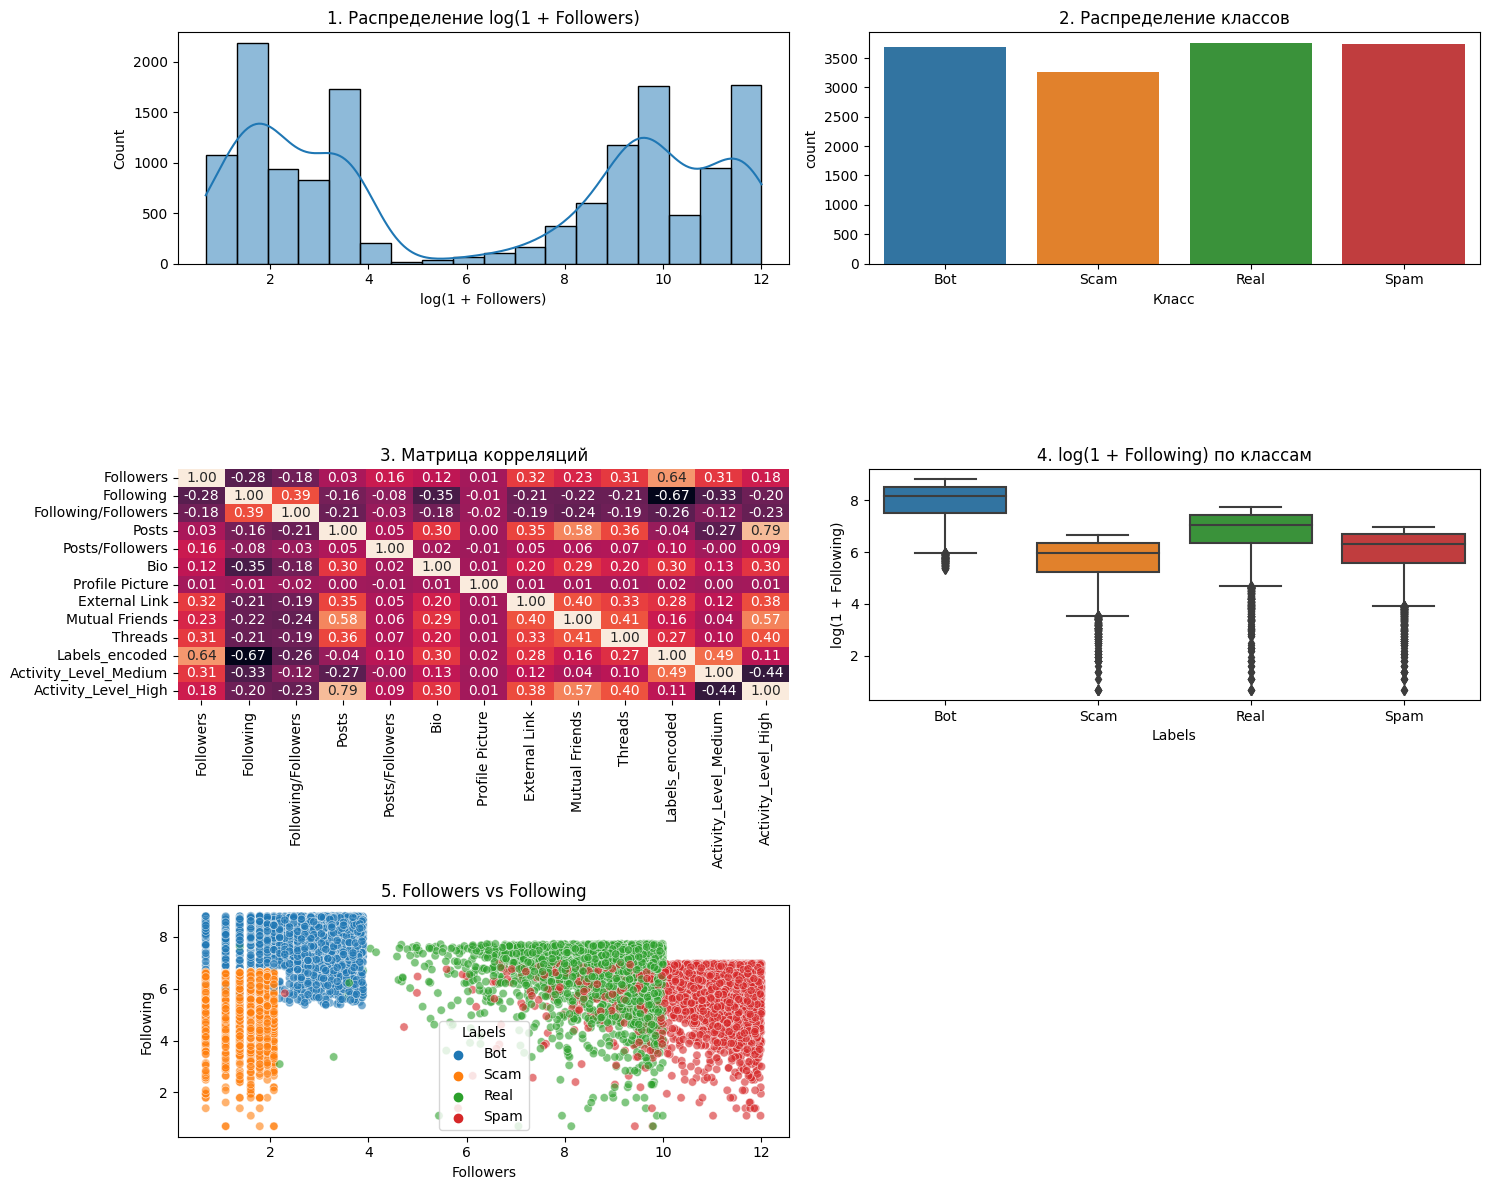

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

sns.histplot(
    np.log1p(df['Followers']),
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Распределение log(1 + Followers)')
axes[0, 0].set_xlabel('log(1 + Followers)')

sns.countplot(
    x='Labels',
    data=df,
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Распределение классов')
axes[0, 1].set_xlabel('Класс')

corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    ax=axes[1, 0],
    cbar=False
)
axes[1, 0].set_title('3. Матрица корреляций')

sns.boxplot(
    x='Labels',
    y=np.log1p(df['Following']),
    data=df,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. log(1 + Following) по классам')
axes[1, 1].set_ylabel('log(1 + Following)')

sns.scatterplot(
    x=np.log1p(df['Followers']),
    y=np.log1p(df['Following']),
    hue='Labels',
    data=df,
    ax=axes[2, 0],
    alpha=0.6
)
axes[2, 0].set_title('5. Followers vs Following')

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

## 5. Формирование признаков и разбиение на выборки

Дополнительно создаётся признак:

`Engagement_Ratio = (Posts + Mutual Friends) / (Followers + 1)`

Далее:

- формируется матрица признаков `X`;
- целевая переменная сохраняется в `y`;
- данные делятся на обучающую и тестовую выборки в пропорции **80/20**;
- для отбора признаков используются `VarianceThreshold` и `SelectKBest`.

In [8]:
df['Engagement_Ratio'] = (
    df['Posts'] + df['Mutual Friends']
) / (df['Followers'] + 1)

X_all = df.select_dtypes(include=[np.number]).drop(
    columns=['Labels_encoded'],
    errors='ignore'
)
y_all = df['Labels_encoded']

print("Количество исходных признаков:", X_all.shape[1])

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train_full)
X_test_var = selector_var.transform(X_test_full)

k_features = min(8, X_train_var.shape[1])

selector_kbest = SelectKBest(
    score_func=f_classif,
    k=k_features
)

X_train_selected = selector_kbest.fit_transform(
    X_train_var,
    y_train
)
X_test_selected = selector_kbest.transform(
    X_test_var
)

var_cols = X_all.columns[selector_var.get_support()]
selected_cols = var_cols[selector_kbest.get_support()]

print(f"\nОтобранные признаки ({len(selected_cols)}):")
for col in selected_cols:
    print(f"- {col}")

print("\nРазмер X_train после отбора:", X_train_selected.shape)
print("Размер X_test после отбора:", X_test_selected.shape)

Количество исходных признаков: 13

Отобранные признаки (8):
- Followers
- Following
- Posts
- Bio
- External Link
- Mutual Friends
- Threads
- Activity_Level_High

Размер X_train после отбора: (11547, 8)
Размер X_test после отбора: (2887, 8)


## 6. Масштабирование признаков

Масштабирование особенно важно для методов, использующих расстояния или градиентную оптимизацию:

- **kNN** — расстояния между объектами зависят от масштаба признаков;
- **MLP** — обучение нейронной сети обычно устойчивее при сопоставимых масштабах признаков.

`StandardScaler` обучается только на `X_train`, а к `X_test` применяется уже обученный scaler.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Масштабирование выполнено.")

Масштабирование выполнено.


## 7. Обучение моделей машинного обучения

Требуется обучить пять моделей. Для каждого метода задаётся базовая конфигурация параметров.

**Базовые параметры:**
- **kNN:** `n_neighbors=5`
- **Decision Tree:** `max_depth=10`
- **Random Forest:** `n_estimators=100`, `max_depth=12`
- **CatBoost:** `iterations=300`, `depth=6`
- **MLP:** `hidden_layer_sizes=(64, 32)`, `max_iter=300`

In [10]:
models = {
    'kNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=12
    ),

    'CatBoost': CatBoostClassifier(
        random_state=42,
        verbose=0,
        iterations=300,
        depth=6
    ),

    'MLP (Neural Net)': MLPClassifier(
        random_state=42,
        max_iter=300,
        hidden_layer_sizes=(64, 32)
    )
}

results = []

for name, model in models.items():
    if name in ['kNN', 'MLP (Neural Net)']:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train_selected
        X_test_model = X_test_selected

    model.fit(X_train_model, y_train)

    y_pred = model.predict(X_test_model)

    y_proba = (
        model.predict_proba(X_test_model)
        if hasattr(model, 'predict_proba')
        else None
    )

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(
        y_test, y_pred, average='macro', zero_division=0
    )
    rec = recall_score(
        y_test, y_pred, average='macro', zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, average='macro', zero_division=0
    )

    roc_auc = (
        roc_auc_score(
            y_test,
            y_proba,
            multi_class='ovr'
        )
        if y_proba is not None
        else np.nan
    )

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Macro)': prec,
        'Recall (Macro)': rec,
        'F1-Score (Macro)': f1,
        'ROC-AUC (OVR)': roc_auc
    })

df_results = pd.DataFrame(results).sort_values(
    by='F1-Score (Macro)',
    ascending=False
)

print('\n=== Результаты обучения моделей ===')
print(df_results.to_string(index=False))


=== Результаты обучения моделей ===
           Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  ROC-AUC (OVR)
   Random Forest  0.971597           0.972839        0.972584          0.972299       0.998698
   Decision Tree  0.968133           0.968884        0.969243          0.968964       0.996539
        CatBoost  0.967787           0.968708        0.968911          0.968641       0.998643
MLP (Neural Net)  0.950121           0.951095        0.951594          0.950288       0.996726
             kNN  0.942847           0.942875        0.943637          0.942954       0.993010


## 8. Основные регулируемые параметры моделей

Описание параметров, которые наиболее заметно могут влиять на результат:

| Метод | Параметр | Что регулирует |
|---|---|---|
| kNN | `n_neighbors` | число соседей при классификации |
| kNN | `weights` | способ взвешивания соседей |
| kNN | `metric` | расстояние между объектами |
| Decision Tree | `max_depth` | максимальную глубину дерева |
| Decision Tree | `min_samples_split` | минимальное число объектов для разделения |
| Decision Tree | `min_samples_leaf` | минимальный размер листа |
| Random Forest | `n_estimators` | количество деревьев |
| Random Forest | `max_depth` | глубину каждого дерева |
| Random Forest | `max_features` | число признаков, рассматриваемых при разделении |
| CatBoost | `iterations` | число итераций бустинга |
| CatBoost | `depth` | глубину деревьев |
| CatBoost | `learning_rate` | шаг обучения |
| MLP | `hidden_layer_sizes` | структуру скрытых слоёв |
| MLP | `alpha` | силу L2-регуляризации |
| MLP | `learning_rate_init` | начальный шаг обучения |
| MLP | `max_iter` | максимальное число итераций |


## 9. Оценка качества классификации

Для многоклассовой классификации используются все пять требуемых метрик:

- **Accuracy** — доля правильных классификаций;
- **Precision** — точность;
- **Recall** — полнота;
- **F1-score** — гармоническое среднее Precision и Recall;
- **ROC-AUC** — площадь под ROC-кривой; для многоклассового случая используется **One-vs-Rest (OVR)**.

Для Precision, Recall и F1 используется `macro`, поэтому каждый из четырёх классов имеет одинаковый вес при усреднении.

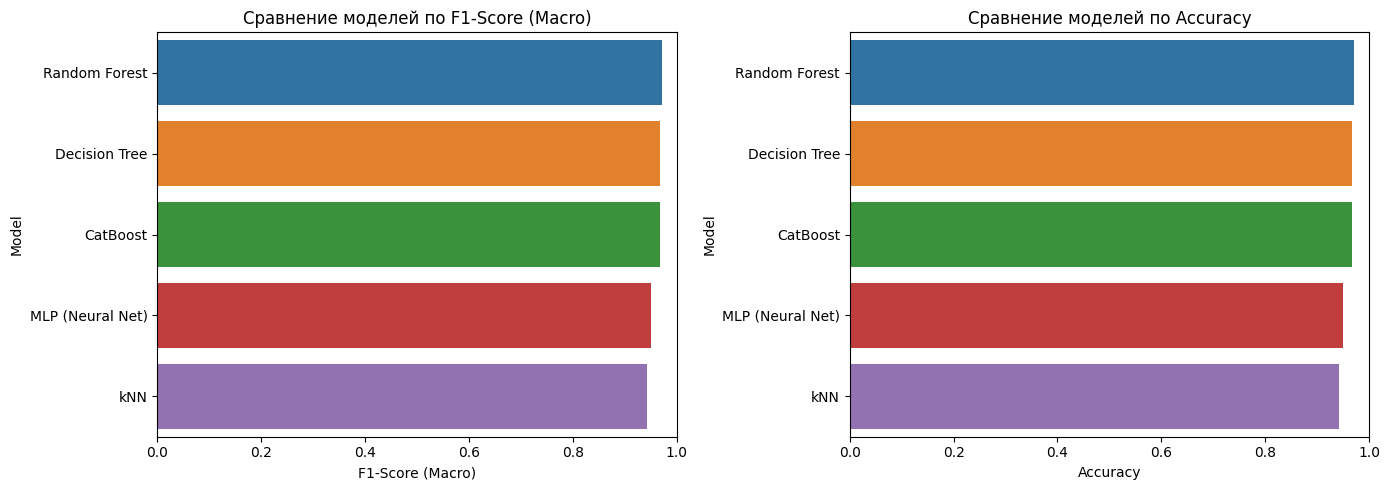

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x='F1-Score (Macro)',
    y='Model',
    data=df_results,
    ax=axes[0]
)
axes[0].set_title('Сравнение моделей по F1-Score (Macro)')
axes[0].set_xlim(0, 1.0)

sns.barplot(
    x='Accuracy',
    y='Model',
    data=df_results,
    ax=axes[1]
)
axes[1].set_title('Сравнение моделей по Accuracy')
axes[1].set_xlim(0, 1.0)

plt.tight_layout()
plt.show()

### 9.1 Подробный отчёт классификации

In [12]:
print('=== Classification Report для всех моделей ===')

for name, model in models.items():

    if name in ['kNN', 'MLP (Neural Net)']:
        X_test_model = X_test_scaled
    else:
        X_test_model = X_test_selected

    y_pred = model.predict(X_test_model)

    print(f'\n--- {name} ---')
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            zero_division=0
        )
    )

=== Classification Report для всех моделей ===

--- kNN ---
              precision    recall  f1-score   support

         Bot       0.97      0.93      0.95       736
        Real       0.94      0.93      0.94       750
        Scam       0.92      0.97      0.94       652
        Spam       0.93      0.95      0.94       749

    accuracy                           0.94      2887
   macro avg       0.94      0.94      0.94      2887
weighted avg       0.94      0.94      0.94      2887


--- Decision Tree ---
              precision    recall  f1-score   support

         Bot       1.00      0.98      0.99       736
        Real       0.96      0.93      0.95       750
        Scam       0.98      1.00      0.99       652
        Spam       0.94      0.96      0.95       749

    accuracy                           0.97      2887
   macro avg       0.97      0.97      0.97      2887
weighted avg       0.97      0.97      0.97      2887


--- Random Forest ---
              precision 

### 9.2 Матрица ошибок

В качестве дополнительной визуализации строится confusion matrix для модели, имеющей максимальный `F1-Score (Macro)` среди базовых моделей.

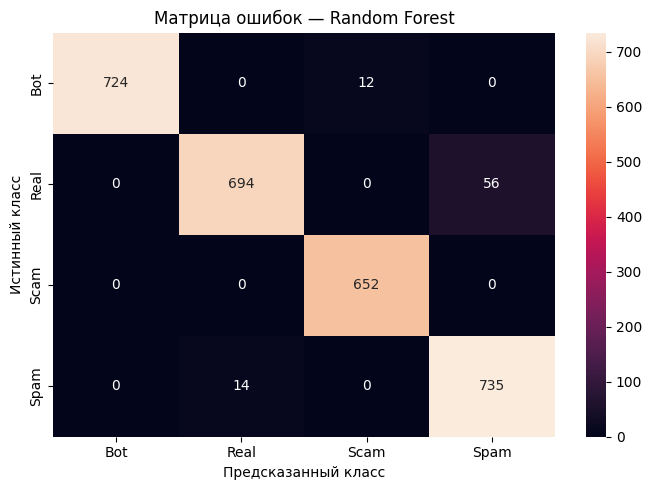

Базовая модель с максимальным macro F1: Random Forest


In [13]:
best_model_name = df_results.iloc[0]['Model']
best_model = models[best_model_name]

if best_model_name in ['kNN', 'MLP (Neural Net)']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test_selected)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(f'Матрица ошибок — {best_model_name}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

print(f'Базовая модель с максимальным macro F1: {best_model_name}')

## 10. Создание отдельного разбиения 60/20/20

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.40,
    random_state=42,
    stratify=y_all
)

X_test, X_new, y_test, y_new = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("=== Разбиение данных ===")
print(f"Обучающая выборка:   {X_train.shape[0]} объектов")
print(f"Тестовая выборка:    {X_test.shape[0]} объектов")
print(f"Новая выборка:       {X_new.shape[0]} объектов")
print(f"Всего:               {len(X_all)} объектов")

print("\nРаспределение классов:")
print("Train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index())
print("\nNew:")
print(y_new.value_counts(normalize=True).sort_index())


=== Разбиение данных ===
Обучающая выборка:   8660 объектов
Тестовая выборка:    2887 объектов
Новая выборка:       2887 объектов
Всего:               14434 объектов

Распределение классов:
Train:
0    0.254965
1    0.259815
2    0.225751
3    0.259469
Name: Labels_encoded, dtype: float64

Test:
0    0.254936
1    0.259785
2    0.225494
3    0.259785
Name: Labels_encoded, dtype: float64

New:
0    0.254936
1    0.259785
2    0.225840
3    0.259439
Name: Labels_encoded, dtype: float64


### 10.1 Перебор параметров

Для каждой модели используется `GridSearchCV` с трёхкратной стратифицированной кросс-валидацией.

В качестве основной метрики настройки используется **F1-score Macro**.

Для kNN и MLP масштабирование включено непосредственно в `Pipeline`. Для варианта с отбором признаков сам отбор (`VarianceThreshold` + `SelectKBest`) тоже находится внутри `Pipeline`. Благодаря этому преобразования выполняются отдельно внутри каждого фолда и не используют данные валидационной части фолда.


In [24]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

structures = {
    "Вариант A — 8 признаков": True,
    "Вариант B — все 13 признаков": False
}

param_grids = {
    "kNN": {
        "model__n_neighbors": [3, 5, 9],
        "model__weights": ["uniform", "distance"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 3]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 12]
    },

    "CatBoost": {
        "model__iterations": [200, 400],
        "model__depth": [4, 6],
        "model__learning_rate": [0.05, 0.10]
    },

    "MLP (Neural Net)": {
        "model__hidden_layer_sizes": [(32, 16), (64, 32)],
        "model__alpha": [0.0001, 0.001]
    }
}


def build_model_pipeline(model_name, use_feature_selection):
    steps = []

    if use_feature_selection:
        steps.append(
            (
                "variance",
                VarianceThreshold(threshold=0.01)
            )
        )
        steps.append(
            (
                "select",
                SelectKBest(
                    score_func=f_classif,
                    k=8
                )
            )
        )

    if model_name == "kNN":
        steps.append(("scaler", StandardScaler()))
        steps.append(
            (
                "model",
                KNeighborsClassifier()
            )
        )

    elif model_name == "Decision Tree":
        steps.append(
            (
                "model",
                DecisionTreeClassifier(
                    random_state=42
                )
            )
        )

    elif model_name == "Random Forest":
        steps.append(
            (
                "model",
                RandomForestClassifier(
                    random_state=42,
                    n_jobs=1
                )
            )
        )

    elif model_name == "CatBoost":
        steps.append(
            (
                "model",
                CatBoostClassifier(
                    random_state=42,
                    verbose=0,
                    thread_count=1,
                    allow_writing_files=False
                )
            )
        )

    elif model_name == "MLP (Neural Net)":
        steps.append(("scaler", StandardScaler()))
        steps.append(
            (
                "model",
                MLPClassifier(
                    random_state=42,
                    max_iter=400,
                    early_stopping=True
                )
            )
        )

    return Pipeline(steps)


searches = {}
cv_rows = []

for structure_name, use_feature_selection in structures.items():
    print("\n" + "=" * 80)
    print(structure_name)
    print("=" * 80)

    for model_name, param_grid in param_grids.items():
        print(f"\nПодбор параметров: {model_name}")

        pipeline = build_model_pipeline(
            model_name,
            use_feature_selection
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="f1_macro",
            cv=cv,
            n_jobs=-1,
            refit=True,
            return_train_score=True
        )

        search.fit(X_train, y_train)

        searches[(structure_name, model_name)] = search

        cv_rows.append(
            {
                "Structure": structure_name,
                "Model": model_name,
                "CV F1-Score (Macro)": search.best_score_,
                "Best Parameters": search.best_params_
            }
        )

        print(f"Лучший CV F1 (Macro): {search.best_score_:.4f}")
        print("Лучшие параметры:")
        print(search.best_params_)

df_cv = pd.DataFrame(cv_rows).sort_values(
    by="CV F1-Score (Macro)",
    ascending=False
)

print("\n=== ЛУЧШИЕ РЕЗУЛЬТАТЫ GRIDSEARCHCV ===")
print(df_cv.to_string(index=False))



Вариант A — 8 признаков

Подбор параметров: kNN
Лучший CV F1 (Macro): 0.9430
Лучшие параметры:
{'model__n_neighbors': 9, 'model__weights': 'distance'}

Подбор параметров: Decision Tree
Лучший CV F1 (Macro): 0.9745
Лучшие параметры:
{'model__max_depth': 10, 'model__min_samples_leaf': 1}

Подбор параметров: Random Forest
Лучший CV F1 (Macro): 0.9757
Лучшие параметры:
{'model__max_depth': 12, 'model__n_estimators': 100}

Подбор параметров: CatBoost
Лучший CV F1 (Macro): 0.9751
Лучшие параметры:
{'model__depth': 6, 'model__iterations': 400, 'model__learning_rate': 0.1}

Подбор параметров: MLP (Neural Net)
Лучший CV F1 (Macro): 0.9421
Лучшие параметры:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64, 32)}

Вариант B — все 13 признаков

Подбор параметров: kNN
Лучший CV F1 (Macro): 0.9586
Лучшие параметры:
{'model__n_neighbors': 3, 'model__weights': 'uniform'}

Подбор параметров: Decision Tree
Лучший CV F1 (Macro): 0.9740
Лучшие параметры:
{'model__max_depth': 10, 'model__min_sampl

Более подробный просмотр результатов перебора. Для каждой пары «структура + модель» выводятся несколько лучших комбинаций параметров. Это позволяет показать какие параметры действительно влияли на результат.

In [25]:
for key, search in searches.items():
    structure_name, model_name = key

    cv_details = pd.DataFrame(search.cv_results_).sort_values(
        by="mean_test_score",
        ascending=False
    ).head(5)

    print("\n" + "=" * 80)
    print(f"{structure_name} | {model_name}")
    print("=" * 80)

    print(
        cv_details[
            [
                "params",
                "mean_test_score",
                "std_test_score",
                "mean_train_score"
            ]
        ].to_string(index=False)
    )



Вариант A — 8 признаков | kNN
                                                 params  mean_test_score  std_test_score  mean_train_score
{'model__n_neighbors': 9, 'model__weights': 'distance'}         0.942961        0.003074          0.999940
{'model__n_neighbors': 5, 'model__weights': 'distance'}         0.942502        0.001863          0.999940
 {'model__n_neighbors': 9, 'model__weights': 'uniform'}         0.941684        0.002144          0.955530
{'model__n_neighbors': 3, 'model__weights': 'distance'}         0.941582        0.002077          0.999940
 {'model__n_neighbors': 3, 'model__weights': 'uniform'}         0.941280        0.002194          0.968951

Вариант A — 8 признаков | Decision Tree
                                                  params  mean_test_score  std_test_score  mean_train_score
  {'model__max_depth': 10, 'model__min_samples_leaf': 1}         0.974530        0.003653          0.985753
  {'model__max_depth': 10, 'model__min_samples_leaf': 3}         0.973

Какие признаки вошли в вариант A?

In [26]:
feature_selector_for_report = Pipeline(
    [
        ("variance", VarianceThreshold(threshold=0.01)),
        ("select", SelectKBest(score_func=f_classif, k=8))
    ]
)

feature_selector_for_report.fit(
    X_train,
    y_train
)

mask_var = feature_selector_for_report.named_steps[
    "variance"
].get_support()

columns_after_variance = X_train.columns[mask_var]

mask_kbest = feature_selector_for_report.named_steps[
    "select"
].get_support()

selected_columns = columns_after_variance[mask_kbest]

print("Признаки варианта A:")
for col in selected_columns:
    print("-", col)


Признаки варианта A:
- Followers
- Following
- Posts
- Bio
- External Link
- Mutual Friends
- Threads
- Activity_Level_High


### 10.2 Изменение структуры набора данных

Сравниваются две структуры:

**Вариант A** — автоматически отобранные 8 признаков.

**Вариант B** — все доступные 13 числовых признаков, включая созданный ранее `Engagement_Ratio`.

Обе структуры проходят один и тот же процесс подбора параметров для пяти моделей.

### 10.3 Анализ влияния изменения структуры

Ниже для обеих структур вычисляются все пять требуемых метрик на одной и той же тестовой выборке.

Отдельно рассчитывается изменение результата:

`Вариант B − Вариант A`.

Положительное значение означает увеличение соответствующей метрики после добавления признаков.

In [27]:
def calculate_metrics(model, X_data, y_true):
    y_pred = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)
        try:
            roc_auc = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr"
            )
        except ValueError:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall (Macro)": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1-Score (Macro)": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "ROC-AUC (OVR)": roc_auc
    }


test_rows = []

for (structure_name, model_name), search in searches.items():
    metrics = calculate_metrics(
        search.best_estimator_,
        X_test,
        y_test
    )

    test_rows.append(
        {
            "Structure": structure_name,
            "Model": model_name,
            **metrics
        }
    )

df_test = pd.DataFrame(test_rows).sort_values(
    by="F1-Score (Macro)",
    ascending=False
)

print("=== ОЦЕНКА ЛУЧШИХ ПАРАМЕТРОВ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(df_test.to_string(index=False))


=== ОЦЕНКА ЛУЧШИХ ПАРАМЕТРОВ НА ТЕСТОВОЙ ВЫБОРКЕ ===
                   Structure            Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  ROC-AUC (OVR)
     Вариант A — 8 признаков    Random Forest  0.975753           0.976595        0.976622          0.976463       0.998948
Вариант B — все 13 признаков    Random Forest  0.974714           0.975420        0.975622          0.975467       0.998999
Вариант B — все 13 признаков         CatBoost  0.974714           0.975472        0.975622          0.975465       0.998956
     Вариант A — 8 признаков         CatBoost  0.973329           0.974047        0.974289          0.974134       0.998919
     Вариант A — 8 признаков    Decision Tree  0.971597           0.972476        0.972622          0.972436       0.995443
Вариант B — все 13 признаков    Decision Tree  0.969172           0.970100        0.970188          0.970046       0.995619
Вариант B — все 13 признаков MLP (Neural Net)  0.962245           0.962766     

In [28]:
metrics_to_compare = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
    "ROC-AUC (OVR)"
]

impact_rows = []

for model_name in param_grids.keys():
    row_a = df_test[
        (df_test["Model"] == model_name)
        & (df_test["Structure"] == "Вариант A — 8 признаков")
    ].iloc[0]

    row_b = df_test[
        (df_test["Model"] == model_name)
        & (df_test["Structure"] == "Вариант B — все 13 признаков")
    ].iloc[0]

    row = {"Model": model_name}

    for metric in metrics_to_compare:
        row[f"{metric} — A"] = row_a[metric]
        row[f"{metric} — B"] = row_b[metric]
        row[f"{metric} — B-A"] = (
            row_b[metric] - row_a[metric]
        )

    impact_rows.append(row)

df_structure_impact = pd.DataFrame(impact_rows)

print("=== ВЛИЯНИЕ ИЗМЕНЕНИЯ СТРУКТУРЫ ПРИЗНАКОВ ===")
print(df_structure_impact.to_string(index=False))


=== ВЛИЯНИЕ ИЗМЕНЕНИЯ СТРУКТУРЫ ПРИЗНАКОВ ===
           Model  Accuracy — A  Accuracy — B  Accuracy — B-A  Precision (Macro) — A  Precision (Macro) — B  Precision (Macro) — B-A  Recall (Macro) — A  Recall (Macro) — B  Recall (Macro) — B-A  F1-Score (Macro) — A  F1-Score (Macro) — B  F1-Score (Macro) — B-A  ROC-AUC (OVR) — A  ROC-AUC (OVR) — B  ROC-AUC (OVR) — B-A
             kNN      0.945618      0.958781        0.013162               0.945403               0.959608                 0.014205            0.946165            0.960042              0.013877              0.945539              0.959793                0.014255           0.995605           0.989813            -0.005792
   Decision Tree      0.971597      0.969172       -0.002425               0.972476               0.970100                -0.002375            0.972622            0.970188             -0.002435              0.972436              0.970046               -0.002390           0.995443           0.995619             

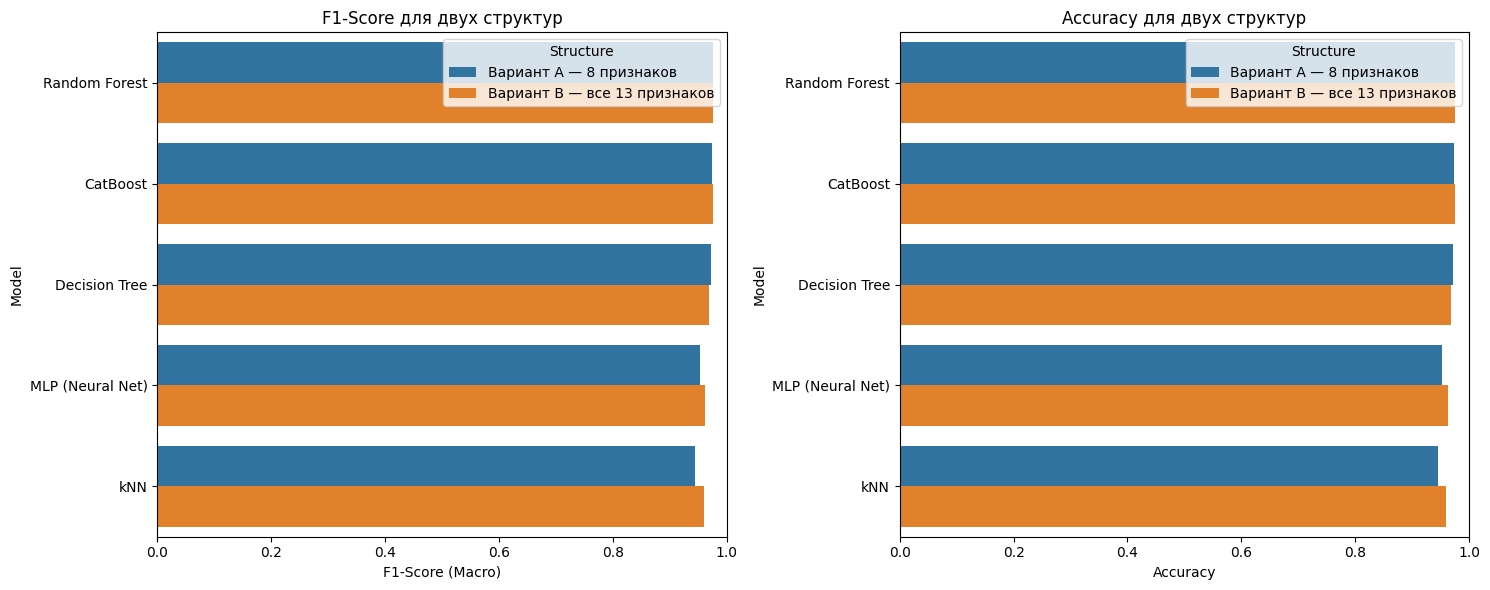

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=df_test,
    x="F1-Score (Macro)",
    y="Model",
    hue="Structure",
    ax=axes[0]
)
axes[0].set_xlim(0, 1.0)
axes[0].set_title("F1-Score для двух структур")

sns.barplot(
    data=df_test,
    x="Accuracy",
    y="Model",
    hue="Structure",
    ax=axes[1]
)
axes[1].set_xlim(0, 1.0)
axes[1].set_title("Accuracy для двух структур")

plt.tight_layout()
plt.show()


### 10.4 Выбор наиболее эффективной модели

Чтобы не выбирать модель по тестовой выборке, окончательный выбор выполняется по максимальному результату **кросс-валидации `F1-score Macro`**.

После выбора модель оценивается на тестовой и затем на независимой новой выборке.


In [30]:
best_cv_row = df_cv.iloc[0]

best_structure = best_cv_row["Structure"]
best_model_name = best_cv_row["Model"]

best_search = searches[
    (best_structure, best_model_name)
]

best_model = best_search.best_estimator_

print("=== ВЫБРАННАЯ МОДЕЛЬ ===")
print(f"Структура данных: {best_structure}")
print(f"Модель:           {best_model_name}")
print(f"CV F1 (Macro):    {best_cv_row['CV F1-Score (Macro)']:.4f}")
print(f"Параметры:        {best_search.best_params_}")

best_test_metrics = calculate_metrics(
    best_model,
    X_test,
    y_test
)

print("\nКачество выбранной модели на тестовой выборке:")
for metric_name, metric_value in best_test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


=== ВЫБРАННАЯ МОДЕЛЬ ===
Структура данных: Вариант B — все 13 признаков
Модель:           Random Forest
CV F1 (Macro):    0.9762
Параметры:        {'model__max_depth': 12, 'model__n_estimators': 100}

Качество выбранной модели на тестовой выборке:
Accuracy: 0.9747
Precision (Macro): 0.9754
Recall (Macro): 0.9756
F1-Score (Macro): 0.9755
ROC-AUC (OVR): 0.9990


### 10.5 Прогноз для новых данных

В текущем ноутбуке отдельный внешний файл с новыми аккаунтами не предоставлен. Поэтому для выполнения требования создаётся **независимая новая выборка** из исходного набора: 20% объектов были заранее отделены от обучения и тестирования и не использовались при подборе параметров.

Это позволяет проверить прогноз на данных, которые модель не видела.


In [31]:
y_new_pred = best_model.predict(X_new)

if hasattr(best_model, "predict_proba"):
    y_new_proba = best_model.predict_proba(X_new)
else:
    y_new_proba = None

print("=== ПРИМЕРЫ ПРОГНОЗОВ НА НОВЫХ ДАННЫХ ===")

new_examples = X_new.head(10).copy()
new_examples["Истинный класс"] = le.inverse_transform(
    y_new.head(10).to_numpy()
)
new_examples["Предсказанный класс"] = le.inverse_transform(
    y_new_pred[:10]
)

print(new_examples.to_string())


=== ПРИМЕРЫ ПРОГНОЗОВ НА НОВЫХ ДАННЫХ ===
       Followers  Following  Following/Followers  Posts  Posts/Followers  Bio  Profile Picture  External Link  Mutual Friends  Threads  Activity_Level_Medium  Activity_Level_High  Engagement_Ratio Истинный класс Предсказанный класс
13308      18000       1753             0.097389   1120     11500.285230    1                1              1               9        0                      0                    1          0.062719           Real                Real
11368      13005        700             0.053825    723     13432.307140    0                1              1               6        0                      0                    1          0.056051           Spam                Spam
823        17349       2052             0.118278   1289     10898.080410    1                0              1               1        1                      0                    1          0.074352           Real                Real
8516          35       1804   

### 10.6 Оценка качества прогноза

=== КАЧЕСТВО ПРОГНОЗА НА НОВОЙ ВЫБОРКЕ ===
        Model                    Structure  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  ROC-AUC (OVR)
Random Forest Вариант B — все 13 признаков  0.972636           0.973184        0.973562          0.973219       0.998648

=== Classification Report на новой выборке ===
              precision    recall  f1-score   support

         Bot       1.00      0.98      0.99       736
        Real       0.97      0.94      0.96       750
        Scam       0.98      1.00      0.99       652
        Spam       0.95      0.97      0.96       749

    accuracy                           0.97      2887
   macro avg       0.97      0.97      0.97      2887
weighted avg       0.97      0.97      0.97      2887



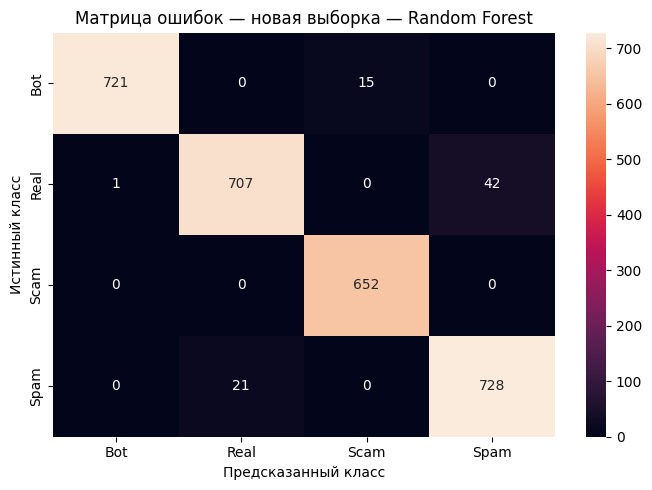

In [32]:
new_metrics = calculate_metrics(
    best_model,
    X_new,
    y_new
)

df_new_metrics = pd.DataFrame(
    [
        {
            "Model": best_model_name,
            "Structure": best_structure,
            **new_metrics
        }
    ]
)

print("=== КАЧЕСТВО ПРОГНОЗА НА НОВОЙ ВЫБОРКЕ ===")
print(df_new_metrics.to_string(index=False))

print("\n=== Classification Report на новой выборке ===")
print(
    classification_report(
        y_new,
        y_new_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

cm_new = confusion_matrix(
    y_new,
    y_new_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_new,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    f"Матрица ошибок — новая выборка — {best_model_name}"
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()


## Итоговый вывод

В ходе исследования был выполнен полный цикл построения и оценки моделей машинного обучения для многоклассовой классификации аккаунтов на четыре класса: **Bot, Real, Scam и Spam**.

На этапе предобработки исходного набора данных были обработаны пропущенные значения, преобразованы категориальные признаки, выполнено кодирование целевой переменной и сформирован набор числовых признаков для дальнейшего обучения моделей. После удаления строк с пропущенными значениями размер набора данных составил **14 434 объекта**.

Были обучены пять моделей машинного обучения: **метод k-ближайших соседей, дерево решений, случайный лес, градиентный бустинг CatBoost и многослойная нейронная сеть**. Для оценки результатов использовались метрики **Accuracy, Precision, Recall, F1-score и ROC-AUC**. По результатам базового обучения на наборе из 8 отобранных признаков наилучший результат показал **Random Forest**: Accuracy = **0.9716**, F1-score Macro = **0.9723**, ROC-AUC = **0.9987**.

Для каждой модели был выполнен перебор гиперпараметров с использованием `GridSearchCV` и трёхкратной стратифицированной кросс-валидации. В качестве основной метрики для подбора параметров использовался **F1-score Macro**. Подбор параметров позволил получить более высокие результаты по сравнению с базовыми моделями. Наилучший результат кросс-валидации показал **Random Forest** при использовании всех 13 признаков: **F1-score Macro = 0.9762**. Для данной модели были выбраны параметры `max_depth = 12` и `n_estimators = 100`.

Также было исследовано влияние изменения структуры набора данных. Сравнивались два варианта: набор из 8 наиболее информативных признаков и полный набор из 13 признаков. Изменение структуры оказало различное влияние на разные модели. Для **kNN** и **MLP** добавление признаков заметно повысило F1-score Macro, тогда как для **Decision Tree** и **Random Forest** результат несколько снизился. Для **CatBoost** использование всех 13 признаков, наоборот, немного улучшило результат. Таким образом, увеличение количества признаков не приводит автоматически к улучшению качества — влияние зависит от используемого алгоритма.

На тестовой выборке наилучший результат среди всех исследованных вариантов показал **Random Forest на 8 признаках**: Accuracy = **0.9758**, Precision = **0.9766**, Recall = **0.9766**, F1-score Macro = **0.9765**, ROC-AUC = **0.9989**. При этом модель Random Forest на всех 13 признаках также показала высокий результат: F1-score Macro = **0.9755**.

Для окончательной проверки выбранной модели была использована независимая новая выборка, которая не участвовала в обучении и подборе параметров. На ней Random Forest, выбранный по результатам кросс-валидации, показал **Accuracy = 0.9726**, **Precision = 0.9732**, **Recall = 0.9736**, **F1-score Macro = 0.9732** и **ROC-AUC = 0.9986**. Небольшое снижение показателей по сравнению с тестовой выборкой является нормальным и при этом качество классификации остаётся высоким.

Таким образом, поставленные задачи исследования были выполнены: проведена предобработка данных, обучены пять моделей машинного обучения, изучены и подобраны гиперпараметры, исследовано влияние структуры набора признаков, выполнено сравнение моделей, а также получен и оценён прогноз на независимых данных. По совокупности проведённых экспериментов **Random Forest показал наиболее высокое качество классификации на данном наборе данных**.
